# Getting started

This notebook contains a brief and basic analysis and checks of our data, to get the first insights of what we are dealing with. It ensures that the data is correctly loaded, cleaned, and documented before proceed to more complex tasks and modelling itself.

First, we will read two important dataframes:
+ What is $\texttt{oncoth2\_data}$ ? This is the main dataset containing clinical and medical information for each patient. It includes a wide range of variables, such as personal characteristics (age, weight, sex), clinical history (previous VTE, comorbidity, cancer type), and blood test results (d-dimer, hb, etc.).
+ What is $\texttt{oncoth2\_traits}$ ? This dataframe serves as a metadata or "data dictionary" file. It provides descriptions for the variables found in $\texttt{oncoth2\_data}$.

Then, an initial inspection is done: checking the size of the dataset (rows and columns) and exploring the data format.

Next, some basic preprocessing (cleaning and preparing the data for analysis):
+ Converting columns that contain dates into the proper datetime format.
+ Filtering the dataset to focus only on patients who provided informed consent and were eligible for the study ($\texttt{df\_eligible}$).
+ Creating new, relevant features, such as calculating the patient's age based on their birth date and the reference date of the study.
+ Deciding whether it's better to consider blood variables, given that they could reflect physiological altercations caused by the developing thrombosis.

# Dataset and Preprocessing

## Read the data

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Oncoth2 Dataset
path_data = "data/oncoth2_data.csv"
df = pd.read_csv(path_data)

# Traits dataset
path_traits = "data/oncoth2_traits.csv"
df_traits = pd.read_csv(path_traits)

In [3]:
# Initial shape

n_rows, n_columns = df.shape
print("Rows: ", n_rows)
print("Columns: ", n_columns)
# df.head()

Rows:  432
Columns:  290


## Data format

To get a first view of what the data looks like, we can check a patients' personal clinical variables.

In [4]:
# For patient-confidentiallity, this will not be shown

# check one patient - id in {1, 432}
# patient_id = 277

# row = df.loc[df["id"] == patient_id].squeeze()
# for col, val in row.items():
#     print(f"{col}: {val}")

There are datetime columns. Just in case, let's redefine them and change their data type them so we can work with them later.

In [5]:
# Redefine datetime columns

date_cols = [col for col in df.columns if col.lower().startswith("date")]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d", errors="coerce")

Now, let's print a brief summary of our data types.

In [6]:
# Format of our data

numeric_cols = df.select_dtypes(include=["number"]).columns
date_cols = df.select_dtypes(include=["datetime64[ns]"]).columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

# Summary table
summary = pd.DataFrame({
    "Type": ["Numeric", "Date", "Categorical"],
    "Count": [len(numeric_cols), len(date_cols), len(categorical_cols)]
})

summary

,Type,Count
0,Numeric,49
1,Date,61
2,Categorical,180


## Keep the patients who consented to the study and the eligible ones

In [7]:
df_eligible = df[(df["informed_consent"] == "Yes") & (df["eligible"] == "Yes")].copy()

In [8]:
# Shape after the first filter

n_rows, n_columns = df_eligible.shape
print("Rows: ", n_rows)
print("Columns: ", n_columns)
# df.head()

Rows:  395
Columns:  290


## Patients distribution

### Add an age column

Since age is a clinically relevant variable in biomedical models, an explicit age feature is added to the dataset. There is a column named $\texttt{date\_death}$ which indicates wether that patient has died; if that's not the case, their age will be computed relative to a fixed reference date (01‑01‑2026), and it will be stored in integer years for interpretability.

In [9]:
# Add the description on the traits dataset
df_traits = df_traits.copy()
df_traits.loc[len(df_traits)] = ["age", "Age of the patient wrt 2026-01-01", "years"]

# Compute age
reference_date = pd.to_datetime("2026-01-01")

# Choose date_death when available, otherwise reference_date
effective_date = df_eligible["date_death"].fillna(reference_date)

df_eligible["age"] = (
    (effective_date - df_eligible["date_birth"]).dt.days / 365.2422
).round().astype(int)

df_eligible[["date_birth", "date_death", "age"]].head()

,date_birth,date_death,age
0,1945-05-30,NaT,81
1,1962-07-28,NaT,63
2,1938-07-25,NaT,87
3,1957-09-18,2018-04-28,61
4,1937-06-24,NaT,89


### Patient Characteristics

In [10]:
def freq_table(df, column):
    tab = (
        df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="count")
    )
    tab["percent"] = (tab["count"] / len(df) * 100).round(2)
    return tab

#### Age

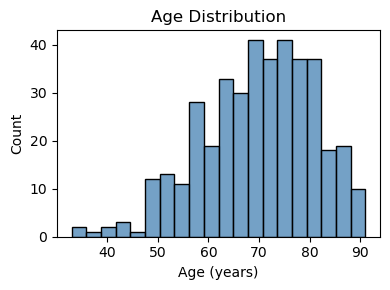

In [11]:
plt.figure(figsize=(4,3))
sns.histplot(df_eligible["age"], bins=20, kde=False, color="steelblue")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.tight_layout()
plt.show()

#### Ethnicity

In [12]:
freq_table(df_eligible, "ethnicity")

,ethnicity,count,percent
0,Caucasian,382,96.71
1,Latin-American,9,2.28
2,Other,2,0.51
3,African,2,0.51


#### Sex

In [13]:
freq_table(df_eligible, "sex")

,sex,count,percent
0,Man,233,58.99
1,Woman,162,41.01


In [14]:
# cross table

joint = pd.crosstab(
    df_eligible["ethnicity"],
    df_eligible["sex"]
)
joint

sex,Man,Woman
ethnicity,,
African,1,1
Caucasian,229,153
Latin-American,3,6
Other,0,2


#### Menopausal status

In [15]:
freq_table(df_eligible, "menopausal_status")

,menopausal_status,count,percent
0,Man,233,58.99
1,Post-menopausal,140,35.44
2,Pre-menopausal,14,3.54
3,Peri-menopausal,5,1.27
4,NaN,3,0.76


#### Hospital

In [16]:
tab = freq_table(df_eligible, "hospital")
tab

,hospital,count,percent
0,Hospital Gregorio Marañón (Madrid),161,40.76
1,Hospital Clínic (Barcelona),68,17.22
2,Hospital Fundación Jimenez Díaz (Madrid),56,14.18
3,Complejo Hospitalario de Ourense,27,6.84
4,Hospital Virgen de las Nieves (Granada),18,4.56
5,Hospital Obispo Polanco (Teruel),17,4.30
6,Hospital de Ciudad Real,13,3.29
7,Hospital Alvaro Cunqueiro (Vigo),10,2.53
8,Hospital Ramón y Cajal (Madrid),9,2.28
9,Hospital Marqués de Valdecilla (Santander),9,2.28


#### Nan values

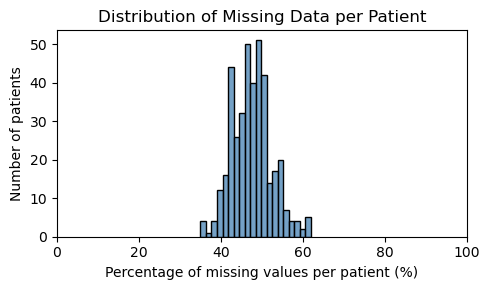

In [17]:
nan_percent = df_eligible.isna().mean(axis=1) * 100
nan_percent = nan_percent.round(0)


plt.figure(figsize=(5,3))
sns.histplot(nan_percent, bins=20, color="steelblue")
plt.xlabel("Percentage of missing values per patient (%)")
plt.ylabel("Number of patients")
plt.title("Distribution of Missing Data per Patient")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## New version - eligible and $\texttt{age}$ column

We have:
+ $\texttt{df\_eligible}$
+ $\texttt{df\_traits}$

### Final dataset shape and comparison

In [18]:
shape_comparison = pd.DataFrame({
    "dataset": ["df", "df_eligible"],
    "rows": [df.shape[0], df_eligible.shape[0]],
    "columns": [df.shape[1], df_eligible.shape[1]]
})

shape_comparison

,dataset,rows,columns
0,df,432,290
1,df_eligible,395,291


In [19]:
# Save the two dataframes

df_eligible.to_csv("dataframes/df_eligible.csv", index=False)
df_traits.to_csv("dataframes/df_traits.csv", index=False)

# Decision for Patient Inclusion and Variable Selection

We need to distinguish between patients that have $\texttt{date\_blood\_test}$ > $\texttt{date\_VTE}$, < or =. It's important to decide:
+ If we want to keep patients that had their blood parameters and variables taken before the VTE, and then consider the blood variables
+ Prioritize having as many patients as possible, and not take into account the blood variables

After careful consideration, it was decided that keeping as many patients as possible was the best idea, given that we already have few patients, and that blood variables are not viable in the sense that maybe 1 day or 1 week prior a VTE, it's already different as usual. This is why we choose to keep all the patients, and drop the blood variables.

Still, a new dataframe is generated with the oposite option, for future scenarios.

We keep
+ $\texttt{df\_eligible\_VTE}$ and $\texttt{df\_traits\_VTE}$, for the chosen option
+ $\texttt{df\_eligible\_blood}$ and $\texttt{df\_traits\_blood}$, for the other option (keep all the variables and less patients).

Let's count how many cases do we have, where $\texttt{date\_VTE}$ is posterior to $\texttt{date\_blood\_test}$, and vice versa. For that, we will also suppose that if $\texttt{date\_VTE}$ is missing, it implies that is goes after the blood test happened.

In [20]:
df_count_blood = df_eligible.copy()

# Remove rows where both dates are missing
df_count_blood = df_count_blood[~(df_count_blood["date_VTE"].isna() & df_count_blood["date_blood_test"].isna())]

# Remove rows where VTE exists but blood test is missing
df_count_blood = df_count_blood[~(df_count_blood["date_VTE"].notna() & df_count_blood["date_blood_test"].isna())]

# Supposing that date_VTE missing implies that it goes after the blood test:
prev = ((df_count_blood["date_blood_test"] < df_count_blood["date_VTE"]) |
        (df_count_blood["date_VTE"].isna())).sum()

equal = (df_count_blood["date_blood_test"] == df_count_blood["date_VTE"]).sum()

post = (df_count_blood["date_blood_test"] > df_count_blood["date_VTE"]).sum()

summary = pd.DataFrame({
    "relation": ["blood test < VTE", "equal", "blood test > VTE"],
    "n_rows": [prev, equal, post]
})

summary

,relation,n_rows
0,blood test < VTE,379
1,equal,2
2,blood test > VTE,14


So, for the first option, of keeping all the variables, we would be doing that to only keep 379 patients.

## $\texttt{df\_eligible\_VTE}$

In this dataframe, we keep all the patients, and drop blood variables.

In [21]:
df_eligible_VTE = df_eligible.copy()
df_traits_VTE = df_traits.copy()

In [22]:
# Blood variables:

blood_vars = [
    "hb", "hb_units", "hb_category",
    "leukocytes", "leukocytes_units", "leukocytes_category",
    "platelets", "platelets_units", "platelets_category",
    "d_dimer", "d_dimer_units", "d_dimer_method", "d_dimer_category",
    "inr", "inr_category",
    "aptt", "aptt_units", "aptt_category",
    "aptt_ratio", "aptt_ratio_category",
    "creatinine", "creatinine_units", "creatinine_category",
    "alkaline_phosphatase", "alkaline_phosphatase_units", "alkaline_phosphatase_category",
    "bilirubin", "bilirubin_units", "bilirubin_category",
    "albumin", "albumin_units", "albumin_category"
]

len(blood_vars)

32

In [23]:
# Drop blood variables and check the size (we sould be keeping the same amount of patients, and 32 less columns)

df_eligible_VTE = df_eligible_VTE.drop(columns=blood_vars)

shape_comparison = pd.DataFrame({
    "dataset": ["df_eligible", "df_eligible_VTE"],
    "rows": [df_eligible.shape[0], df_eligible_VTE.shape[0]],
    "columns": [df_eligible.shape[1], df_eligible_VTE.shape[1]]
})

shape_comparison

,dataset,rows,columns
0,df_eligible,395,291
1,df_eligible_VTE,395,259


In [24]:
# Drop the rows from traits and check the size (we sould be seeing 43 less traits)

df_traits_VTE = df_traits_VTE[~df_traits_VTE["trait"].isin(blood_vars)]

shape_comparison = pd.DataFrame({
    "dataset": ["df_traits", "df_traits_VTE"],
    "rows": [df_traits.shape[0], df_traits_VTE.shape[0]],
    "columns": [df_traits.shape[1], df_traits_VTE.shape[1]]
})

shape_comparison

,dataset,rows,columns
0,df_traits,333,3
1,df_traits_VTE,301,3


In [25]:
df_eligible_VTE.to_csv("dataframes/df_eligible_VTE.csv", index=False)
df_traits_VTE.to_csv("dataframes/df_traits_VTE.csv", index=False)

## $\texttt{df\_eligible\_blood}$

In this dataframe, we only keep patients whose $\texttt{date\_VTE}$ is posterior to $\texttt{date\_blood\_test}$. This approach would aim to study the following blood variables:

+ $\texttt{hb}$
+ $\texttt{leukocytes}$
+ $\texttt{platelets}$
+ $\texttt{d\_dimer}$
+ $\texttt{aptt}$
+ $\texttt{creatinine}$
+ $\texttt{alkaline\_phosphatase}$
+ $\texttt{bilirubin}$
+ $\texttt{albumin}$

In [26]:
blood_vars = [
    "hb", "leukocytes", "platelets", "d_dimer", "aptt", 
    "creatinine", "alkaline_phosphatase", "bilirubin", "albumin"
]

df_traits.loc[df_traits["trait"].isin(blood_vars), ["trait", "definition"]]

,trait,definition
98,hb,Hemoglobin levels in blood
101,leukocytes,Leukocytes levels in blood
104,platelets,Platelets levels in blood
107,d_dimer,D-dimer levels in blood
113,aptt,Activated Partial Thromboplastin Time (APTT)
118,creatinine,Creatinine levels in blood
121,alkaline_phosphatase,Alkaline phosphatase levels in blood
124,bilirubin,Bilirubin levels in blood
127,albumin,Albumin levels in blood


### Check blood variables' units

As there are different hospitals in this dataset, we also need to check whether these blood variables were taking in the same unit.

In [27]:
# Check that blood variables are in the same unit

unit_blood_vars = [
    "hb_units", "leukocytes_units", "platelets_units", "d_dimer_units", "aptt_units", 
    "creatinine_units", "alkaline_phosphatase_units", "bilirubin_units", "albumin_units"
]

rows = []

for col in unit_blood_vars:
    unique_units = df[col].dropna().unique()
    unique_units = [str(u) for u in unique_units]  
    units_str = ", ".join(unique_units)
    rows.append({"variable": col, "units": units_str})

unit_blood_vars_table = pd.DataFrame(rows)
unit_blood_vars_table

,variable,units
0,hb_units,g/dL
1,leukocytes_units,x10^3/microL
2,platelets_units,x10⁹/L
3,d_dimer_units,"ng/mL, ng/ml"
4,aptt_units,s
5,creatinine_units,mg/dL
6,alkaline_phosphatase_units,UI/L
7,bilirubin_units,mg/dL
8,albumin_units,g/dL


Thankfully, all the blood variables are given in the same units, so we don't have to do any transformation to them. The only variable that has two separated "different" units is $\texttt{d\_dimer}$, but, as we can see, it's the same.

Now, let's go on with the selection and reduction of our dataframe.

### Dropping patients

In [28]:
# Using the doe before, when looking at how many patients had their blood test taken after their VTE or not
# Check the size (we sould be seeing 379 patients)

VTE_after = (
    (df_eligible["date_blood_test"] < df_eligible["date_VTE"]) |
    (df_eligible["date_VTE"].isna())
)

df_eligible_blood = df_eligible[VTE_after].copy()
df_traits_blood = df_traits.copy()

shape_comparison = pd.DataFrame({
    "dataset": ["df_eligible", "df_eligible_blood"],
    "rows": [df_eligible.shape[0], df_eligible_blood.shape[0]],
    "columns": [df_eligible.shape[1], df_eligible_blood.shape[1]]
})

shape_comparison

,dataset,rows,columns
0,df_eligible,395,291
1,df_eligible_blood,379,291


In [29]:
df_eligible_blood.to_csv("dataframes/df_eligible_blood.csv", index=False)
df_traits_blood.to_csv("dataframes/df_traits_blood.csv", index=False)

# VTE final counts

In [30]:
vte_rec = pd.crosstab(
    df_eligible["sex"],
    df_eligible["VTE"],
    dropna=False
)

# Add row totals
vte_rec["Total"] = vte_rec.sum(axis=1)

# Add column totals
vte_rec.loc["Total"] = vte_rec.sum(axis=0)

vte_rec

VTE,No,Yes,NaN,Total
sex,,,,
Man,179,50,4,233
Woman,117,45,0,162
Total,296,95,4,395
